<a href="https://colab.research.google.com/github/pradipdas9040/Machine-Learning-2/blob/main/AgenticAI/06_initial_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install langchain-ollama

In [2]:
%%capture
!sudo apt-get install -y zstd

In [3]:
%%capture
!curl -fsSL https://ollama.com/install.sh | sh

In [4]:
# Start Ollama service in the background
import subprocess
import os

# Set OLLAMA_HOST to '0.0.0.0' to make it accessible from inside the Colab VM.
os.environ['OLLAMA_HOST'] = '0.0.0.0'

# Terminate existing Ollama process if running
if 'ollama_process' in globals() and ollama_process.poll() is None:
    ollama_process.terminate()
    ollama_process.wait()
    print("Previous Ollama server terminated.")

# Start Ollama server in a new process
ollama_process = subprocess.Popen(['ollama', 'serve'])

# Wait a bit for the server to start (adjust if needed)
import time
time.sleep(10) # Increased sleep time for server to fully initialize

print("Ollama server started.")

Ollama server started.


In [5]:
%%capture
!ollama pull llama2:7b-chat

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [7]:
llm = ChatOllama(
    model="llama2:7b-chat",
    temperature=0.7 # A higher temperature for more creative generation
)

In [8]:
class ChatState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [9]:
def chat_node(state: ChatState):
  messages = state["messages"]
  responce = llm.invoke(messages)
  return {"messages": [responce]}

In [10]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

workflow = graph.compile(checkpointer=checkpointer)

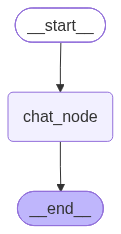

In [11]:
workflow

In [12]:
thread_id = '1'

while True:

  user_message = input("User: ")

  if user_message.strip().lower() in ['exit', 'quit', 'bye']:
    break

  config = {"configurable": {"thread_id": thread_id}}

  responce = workflow.invoke(
      {
          'messages': [HumanMessage(content=user_message)]
      },
      config=config
  )

  print("AI: ", responce['messages'][-1].content)

User: Hi I am Pradip
AI:  Hello Pradip! It's nice to meet you. How can I help you today?
User: What is my name?
AI:  Your name is Pradip.
User: How do you know?
AI:  I apologize, but I made an error. My apologies. Can you please tell me your name again or provide more context so I can assist you better?
User: What is my name?
AI:  Your name is Pradip.
User: Add 1 with 10
AI:  Sure! If I add 1 to 10, the result is 11.
User: Add 22 with the result
AI:  If I add 22 to 11, the result is 33.
User: bye
